In [23]:
# Check Python environment
import sys
print("Python executable:", sys.executable)

# Install required packages in the current environment
!{sys.executable} -m pip install -q matplotlib seaborn setuptools

# Data handling
import pandas as pd

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter Notebook setting
%matplotlib inline

print("All libraries imported successfully!")


Python executable: C:\Users\Dipika\AppData\Local\Programs\Python\Python313\python.exe
All libraries imported successfully!



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Dipika\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


# load Data

In [24]:

df = pd.read_csv("clean_dataset.csv")

# Clean Column Names

In [25]:

df.columns = df.columns.str.strip()
print(df.columns)
print(df.head())

Index(['date', 'steps', 'calories_burned', 'distance_km', 'active_minutes',
       'sleep_hours', 'heart_rate_avg', 'workout_type', 'weather_conditions',
       'location', 'mood'],
      dtype='str')
         date  steps  calories_burned  distance_km  active_minutes  \
0  2023-01-01   4530          2543.02        16.10             613   
1  2023-01-01  11613          1720.76         8.10             352   
2  2023-01-01  27335          1706.35         3.57             236   
3  2023-01-01  13459          2912.38         6.41            1329   
4  2023-01-01  15378          3344.51        17.88              52   

   sleep_hours  heart_rate_avg workout_type weather_conditions location  \
0          1.5             176      Walking              Clear     Park   
1          6.3             128      Cycling                Fog     Park   
2          6.7             134         Yoga               Snow     Park   
3         11.6             116     Swimming               Rain   Office   
4  

# Remove Unwanted Column

In [26]:
df = df.drop(columns=['date'])


# Create FITNESS

In [27]:




df['fitness_score'] = (
    df['steps'] +
    df['calories_burned'] +
    df['active_minutes']
) / 3

In [28]:

df['fitness'] = pd.qcut(
    df['fitness_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)


In [29]:
print(df['fitness'].value_counts())

fitness
Low       333334
Medium    333333
High      333333
Name: count, dtype: int64


# Define X and y

In [30]:

y = df['fitness']
X = df.drop(columns=['fitness', 'fitness_score'])


# Encode Target (fitness)

In [31]:
le = LabelEncoder()
y = le.fit_transform(y)

# One-Hot Encode Features

In [32]:


X = pd.get_dummies(X, drop_first=True)

print(X.head())

   steps  calories_burned  distance_km  active_minutes  sleep_hours  \
0   4530          2543.02        16.10             613          1.5   
1  11613          1720.76         8.10             352          6.3   
2  27335          1706.35         3.57             236          6.7   
3  13459          2912.38         6.41            1329         11.6   
4  15378          3344.51        17.88              52          7.4   

   heart_rate_avg  workout_type_Gym Workout  workout_type_Running  \
0             176                     False                 False   
1             128                     False                 False   
2             134                     False                 False   
3             116                     False                 False   
4              84                     False                 False   

   workout_type_Swimming  workout_type_Walking  ...  weather_conditions_Fog  \
0                  False                  True  ...                   False   


# Random Forest

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

In [35]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [36]:
y_pred = model.predict(X_test)




In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred))


print(classification_report(y_test, y_pred))

Accuracy: 0.987075
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     66667
           1       0.99      0.99      0.99     66667
           2       0.98      0.98      0.98     66666

    accuracy                           0.99    200000
   macro avg       0.99      0.99      0.99    200000
weighted avg       0.99      0.99      0.99    200000



# Naive bayes

In [38]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.95804
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     66667
           1       0.97      0.97      0.97     66667
           2       0.94      0.94      0.94     66666

    accuracy                           0.96    200000
   macro avg       0.96      0.96      0.96    200000
weighted avg       0.96      0.96      0.96    200000



# Scale data For SVM

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_svm = scaler.fit_transform(X_train)
X_test_svm = scaler.transform(X_test)

# Train SVM

In [40]:
svm_model = SVC(kernel='linear')

svm_model.fit(X_train_svm, y_train)

y_pred_svm = svm_model.predict(X_test_svm)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.99957
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66667
           1       1.00      1.00      1.00     66667
           2       1.00      1.00      1.00     66666

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



# Confusion matrices(For all models)

In [41]:
from sklearn.metrics import confusion_matrix

print("Random Forest:\n", confusion_matrix(y_test, y_pred))

print("\nNaive Bayes:\n", confusion_matrix(y_test, y_pred_nb))

print("\nSVM:\n", confusion_matrix(y_test, y_pred_svm))

Random Forest:
 [[65932     0   735]
 [    0 65842   825]
 [  532   493 65641]]

Naive Bayes:
 [[64588     0  2079]
 [    0 64545  2122]
 [ 2063  2128 62475]]

SVM:
 [[66640     0    27]
 [    0 66653    14]
 [   14    31 66621]]


# Model comparison

In [42]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Random Forest Accuracy: 0.987075
Naive Bayes Accuracy: 0.95804
SVM Accuracy: 0.99957


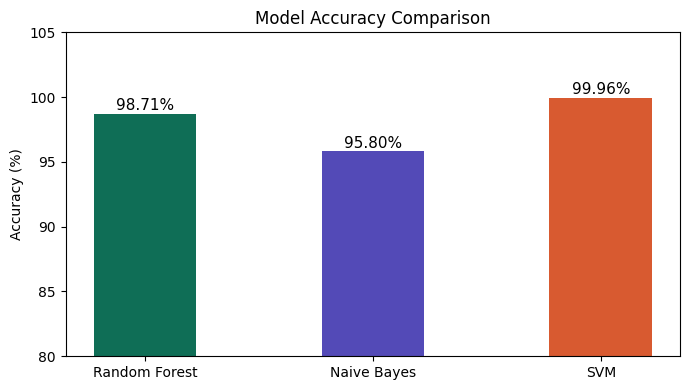

In [43]:
# 1. Accuracy Comparison Bar Chart
models = ['Random Forest', 'Naive Bayes', 'SVM']
accs = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_svm)
]

plt.figure(figsize=(7, 4))
bars = plt.bar(models, [a*100 for a in accs], color=['#0F6E56','#534AB7','#D85A30'], width=0.45)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc*100:.2f}%', ha='center', fontsize=11)
plt.ylim(80, 105)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.tight_layout()
plt.show()

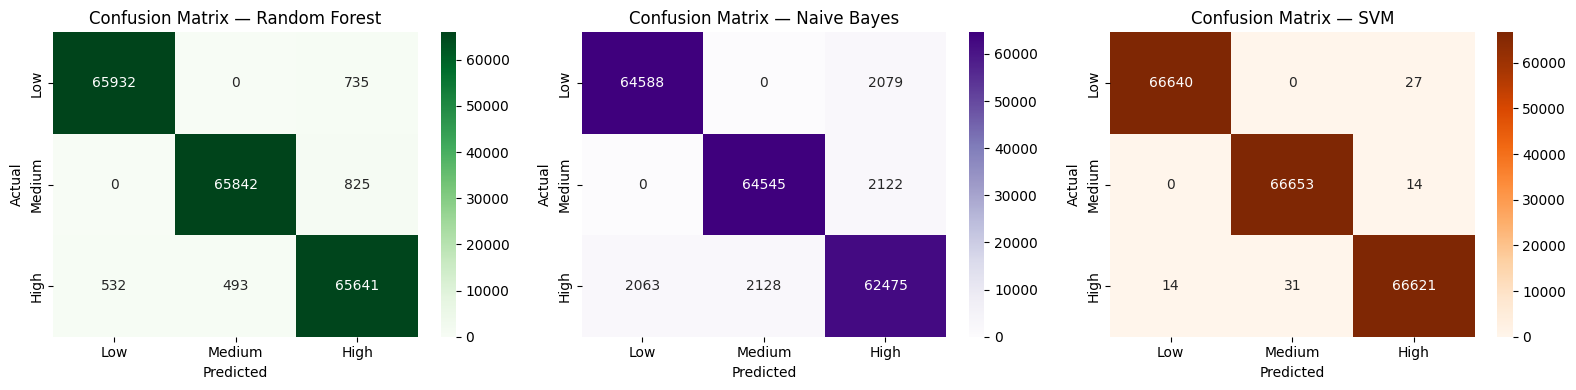

In [44]:
# 2. Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
class_names = ['Low', 'Medium', 'High']

for ax, y_p, title, cmap in zip(
    axes,
    [y_pred, y_pred_nb, y_pred_svm],
    ['Random Forest', 'Naive Bayes', 'SVM'],
    ['Greens', 'Purples', 'Oranges']
):
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

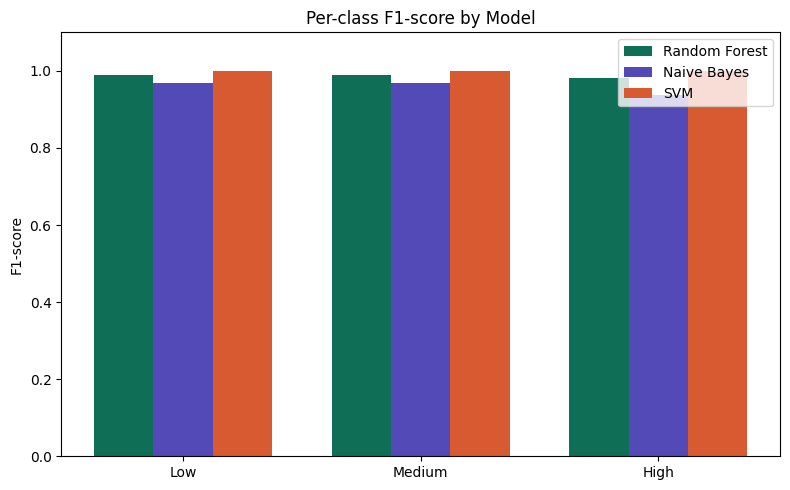

In [45]:
# 3. Per-class F1-score comparison
import numpy as np

def get_f1(y_true, y_p):
    report = classification_report(y_true, y_p, output_dict=True)
    return [report[str(i)]['f1-score'] for i in range(3)]

rf_f1  = get_f1(y_test, y_pred)
nb_f1  = get_f1(y_test, y_pred_nb)
svm_f1 = get_f1(y_test, y_pred_svm)

x = np.arange(3)
w = 0.25
plt.figure(figsize=(8, 5))
plt.bar(x - w, rf_f1,  w, label='Random Forest', color='#0F6E56')
plt.bar(x,     nb_f1,  w, label='Naive Bayes',   color='#534AB7')
plt.bar(x + w, svm_f1, w, label='SVM',           color='#D85A30')
plt.xticks(x, class_names)
plt.ylim(0, 1.1)
plt.ylabel('F1-score')
plt.title('Per-class F1-score by Model')
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# 4. Feature Importances
fi = pd.Series(rf_model.feature_importances_, index=X.columns)\
       .sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
fi.plot(kind='barh', color='#534AB7')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

NameError: name 'rf_model' is not defined

# Comparison Table

In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Naive Bayes", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ]
})

print(results)

# Save Result

In [ ]:
results.to_csv("model_comparison.csv", index=False)

print("✅ Comparison file saved")

# Final Confusion Matrix summary

In [ ]:
print("RF:\n", confusion_matrix(y_test, y_pred))
print("NB:\n", confusion_matrix(y_test, y_pred_nb))
print("SVM:\n", confusion_matrix(y_test, y_pred_svm))